## [Luis Alejandro Rodríguez Arenas](https://luigitoby.github.io/)
## Cod. 202321287
# Taller 4

# Librerías

In [3]:
from sympy import symbols, Matrix, pi, cos, sin, simplify, eye, solve, latex, atan2, pprint, init_printing, Derivative, sqrt, diff, Eq, tan, integrate
from sympy.physics.vector import dynamicsymbols, init_vprinting, ReferenceFrame
from numpy import deg2rad, linspace
import matplotlib.pyplot as plt
init_vprinting(use_latex='mathjax')

# Sobre diagramas y procesos a mano
Para todos los puntos de adjunta un archivo .pdf con diagramas y procesos a fines, para mayor claridad del proceso que se llevo acabo en cada ejercicio.

# ej1 
Las tres pequeñas esferas están soldadas al marco rígido liviano, el cual está girando
en un plano horizontal alrededor de un eje vertical que pasa por el punto O, con una
velocidad angular de 20 rad/s. A partir del instante t=0 se aplica un momento par
constante de 30Nm, grafique la velocidad angular durante los primeros 5 segundos del
movimiento.

In [4]:
t = symbols('t')
omega = dynamicsymbols('omega')
M, I, w0 = symbols('M I w0')

# Ecuación del momento angular neto
eq_motion = Eq(diff(omega, t), M/I)
display(eq_motion)


omega_t = integrate(eq_motion.rhs, t) + w0
display(Eq(omega, omega_t))

# Datos del problema
M_val = 30      # N·m
m1, m2, m3 = 4, 3, 3  # kg
r1, r2, r3 = 0.4, 0.5, 0.6  # m
w0_val = 20     # rad/s

# Cálculo del momento de inercia total
I_val = m1*r1**2 + m2*r2**2 + m3*r3**2
display(Eq(I, I_val))


    M
ω̇ = ─
    I

         M⋅t
ω = w₀ + ───
          I 

I = 2.47

In [5]:
omega_expr = simplify(omega_t.subs({M: M_val, I: I_val, w0: w0_val}))
display(Eq(omega, omega_expr))


ω = 12.1457489878543⋅t + 20

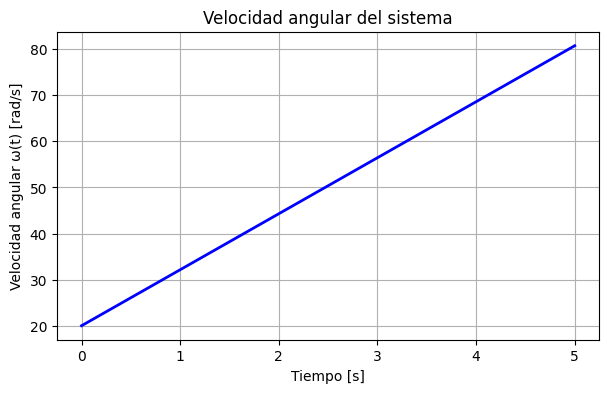

In [6]:
import numpy as np

# Tiempo (s)
t_vals = np.linspace(0, 5, 200)

# Función numérica
omega_func = lambda t: float(omega_expr.subs({'t': t}))
omega_vals = [omega_func(t) for t in t_vals]

# Gráfica
plt.figure(figsize=(7,4))
plt.plot(t_vals, omega_vals, color='b', lw=2)
plt.title('Velocidad angular del sistema')
plt.xlabel('Tiempo [s]')
plt.ylabel('Velocidad angular ω(t) [rad/s]')
plt.grid(True)
plt.show()


In [ ]:
omega_5 = omega_expr.subs(t, 5)
display(Eq(omega.subs(t, 5), omega_5))
float(omega_5)

ω(5) = 80.7287449392713

80.72874493927125

## Análisis
El valor final obtenido es:  
a_b = -1.941 m/s^2 
El signo negativo indica que la aceleración va en sentido opuesto al eje positivo de la guía, es decir, el deslizador está siendo frenado o empujado hacia atrás respecto a la orientación elegida. La magnitud es coherente con las dimensiones del mecanismo y la velocidad angular aplicada, confirmando que la solución es consistente tanto física como geométricamente.

### NOTA La solución a mano se encuentra en el .pdf adjunto, y esta larga, claramente mejor hacer cálculo simbólico